# Importing Required Libraries

In this section, the required Python libraries for data
processing, numerical computations, random sampling,
and visualization are imported into the environment.


In [2]:
# کتابخانه‌های اصلی پروژه

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

## 📥 Loading the Dataset



# Chunk Processing

Due to the extremely large size of the dataset,
the data is processed in chunks in order to reduce
memory consumption and improve performance.

In [3]:
# Process dataset in chunks

# Function for reading dataset in chunks

def read_in_chunks(
    file_path,
    chunk_size=1000000,
    usecols=None
):

    for chunk in pd.read_csv(
        file_path,
        chunksize=chunk_size,
        usecols=usecols
    ):
        yield chunk

# Dataset Normalization

In this step, all text columns in the dataset are
normalized in order to unify Persian and Arabic
characters.

Because the dataset is extremely large, the file is
processed in chunks and a new normalized dataset is
generated for future operations.


In [11]:
# Function for normalizing Persian text

def normalize_text(text):

    if isinstance(text, str):

        # Replace Arabic characters with Persian characters
        text = text.replace('ي', 'ی')
        text = text.replace('ك', 'ک')

        # Remove extra spaces
        text = text.strip()

    return text



# Output file name

output_file = "normalized_bank_data.csv"


# To write header only once

first_chunk = True


# Process dataset in chunks

for chunk in read_in_chunks("Bank NIT DB.csv", 1000000):

    # Select text columns
    text_columns = chunk.select_dtypes(
        include=['object', 'string']
    ).columns

    # Normalize all text columns
    for col in text_columns:

        chunk[col] = chunk[col].astype(str).apply(normalize_text)

    # Save normalized chunk
    chunk.to_csv(
        output_file,
        mode='a',
        index=False,
        header=first_chunk
    )

    first_chunk = False

chunk.head()


print("Dataset normalization completed.")

Dataset normalization completed.


# Question 1

In this section, 10 random records are selected
from the dataset in order to analyze the structure
and informational layers of the Noushirvani Bank data.

In [4]:
# انتخاب ۱۰ رکورد تصادفی
for chunk in read_in_chunks("normalized_bank_data.csv" , 1000000) :

    sample_records = chunk.sample(10)

    break

# نمایش رکوردها

sample_records

,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE
774669,774670,امیر رضا,ناصر,1358-05-20,NaN,NaN,محلات,مرکزی
347540,347541,محمد شکری حسینی,خلیل,1363-04-17,NaN,NaN,ارومیه,آذربایجان غربی
436474,436475,هدایت گراوند,علی عباس,1357-09-05,تهران,تهران,کوهدشت,لرستان
142277,142278,یوسف کمالی فرد,حبیب اله,1370-08-26,NaN,NaN,ممسنی,فارس
197406,197407,زهرا زارع,علی همت,1374-03-08,شیراز,فارس,خرامه,فارس
40792,40793,مقصود علی پورنوتاش,علی,1337-02-02,تهران,تهران,تبریز,آذربایجان شرقی
823371,823372,ولی یوسفی,حمزه علی,1351-04-04,تهران,تهران,ترکمانچای,آذربایجان شرقی
678648,678649,مریم زهره ادبی,محمدرضا,1361-04-05,کرمان,کرمان,سیرجان,کرمان
275390,275391,فرزانه صادق زاده صفاریان,حمید,1362-06-23,NaN,NaN,مشهد,خراسان رضوی
917512,917513,فاطمه حسین پورنوا,فیض الله,1334-10-04,مراغه,اذربایجان شرقی,مراغه,آذربایجان شرقی


# Analizing the Records

In [ ]:
# Display dataset dimensions
for chunk in read_in_chunks("normalized_bank_data.csv" , 1000000) :
    print(chunk.shape)

    # Display column names

    print(chunk.columns)

    break

(1000000, 8)
Index(['national_code', 'FULL_NAME', 'FATHER_NAME', 'BIRTH_DATE', 'CITY_NAME',
       'PROVINCE_NAME', 'BIRTH_CITY', 'BIRTH_PROVINCE'],
      dtype='str')


# Question 2

In this section, missing residence information is handled.

For records where the residence city or province is missing,
the corresponding birth city and birth province values are used.

This helps maintain geographical consistency in the dataset.

In [ ]:
# Fill missing residence city using birth city
# only when birth city exists
sum1 = sum2 = 0
for chunk in read_in_chunks("normalized_bank_data.csv" , 1000000) :
    city_condition = (
        chunk['CITY_NAME'].isna() &
        chunk['BIRTH_CITY'].notna()
    )

    chunk.loc[city_condition, 'CITY_NAME'] = chunk.loc[
        city_condition,
        'BIRTH_CITY'
    ]


    # Fill missing residence province using birth province
    # only when birth province exists

    province_condition = (
        chunk['PROVINCE_NAME'].isna() &
        chunk['BIRTH_PROVINCE'].notna()
    )

    chunk.loc[province_condition, 'PROVINCE_NAME'] = chunk.loc[
        province_condition,
        'BIRTH_PROVINCE'
    ]


    # Display remaining missing values
    x , y = chunk[['CITY_NAME', 'PROVINCE_NAME']].isnull().sum()
    sum1 += x
    sum2 += y

print(f"CITY_NAME = {sum1} , PROVINCE_NAME = {sum2}")


print("--------------------")

CITY_NAME = 363515 , PROVINCE_NAME = 364645
--------------------


# Analysis

The missing residence locations were updated only for

records that had valid birth location information.

This method prevents invalid replacements and improves

the consistency of geographical data in the dataset.

# Question 3

## Description

The national code values in the dataset have different lengths.

Since the standard Iranian national code must contain
exactly 10 digits, all values in the national code column
are converted into a unified 10-digit format.

## Objective

Standardize all national codes in order to improve
data consistency and prevent identification errors.

In [8]:
for chunk in read_in_chunks("normalized_bank_data.csv" , 1000000) :
    # Convert national codes to string format

    chunk['national_code'] = chunk['national_code'].astype(str)

    # Remove extra spaces

    chunk['national_code'] = chunk['national_code'].str.strip()


    # Convert all national codes to 10 digits
    # by adding leading zeros

    chunk['national_code'] = chunk['national_code'].str.zfill(10)


    # Display sample national codes

chunk[['national_code']].head(10)

,national_code
32000000,0032000001
32000001,0032000002
32000002,0032000003
32000003,0032000004
32000004,0032000005
32000005,0032000006
32000006,0032000007
32000007,0032000008
32000008,0032000009
32000009,0032000010


# Question 4

## Description

In this section, the dataset is searched in order to
identify all individuals whose last name is "علیزاده"
and whose residence province is "هرمزگان".

## Objective

Filter suspicious records related to the financial
investigation described in the project scenario.

In [ ]:
# List for storing filtered records

alizadeh_people = []


for chunk in read_in_chunks("normalized_bank_data.csv", 1000000):

    # Extract last name
    chunk['LAST_NAME'] = chunk['FULL_NAME'].str.split().str[-1]

    # Filter records
    filtered = chunk[
        (chunk['LAST_NAME'].str.strip() == 'علیزاده') &
        (chunk['PROVINCE_NAME'].str.strip() == 'هرمزگان')
    ]

    # Store filtered chunk
    alizadeh_people.append(filtered)


# Merge all filtered chunks

final_fd = pd.concat(
    alizadeh_people,
    ignore_index=True
)


# Display result shape

print(final_fd.shape)


# Display sample results

final_fd.head()

(300, 9)


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,LAST_NAME
0,27291,سعید علیزاده,فریدون,1363-06-29,بندرعباس,هرمزگان,بندرعباس,هرمزگان,علیزاده
1,36467,امیرعباس علیزاده,علی,1385-10-14,بندرعباس,هرمزگان,بندرعباس,هرمزگان,علیزاده
2,115490,کبری حاجی علیزاده,مرید,1358-01-01,میناب,هرمزگان,شهربابک,کرمان,علیزاده
3,130116,معراج علیزاده,اسلام,1384-02-01,میناب,هرمزگان,میناب,هرمزگان,علیزاده
4,455097,مصطفی علیزاده,محمود,1367-06-30,بندرعباس,هرمزگان,بندرعباس,هرمزگان,علیزاده


# Question 5

## Description

In this section, individuals whose last name is
"حسنپور" and whose residence province is "اصفهان"
are identified from the dataset.

A new feature called "ADDRESS" is then added to
the dataset, and the value "خوابگاه امینیان" is
assigned to the matching records.

## Objective

Provide temporary residence information for the
identified individuals according to the project scenario.

In [ ]:
hasanpour_people = []

for chunk in read_in_chunks("normalized_bank_data.csv",1000000) :

    # Extract last name from full name

    chunk['LAST_NAME'] = chunk['FULL_NAME'].str.split().str[-1]


    # Create ADDRESS column if it does not exist

    chunk['ADDRESS'] = np.nan


    # Identify target individuals

    hasanpour_condition = (
        (chunk['LAST_NAME'] == 'حسنپور') &
        (chunk['PROVINCE_NAME'] == 'اصفهان')
    )



    chunk['ADDRESS'] = chunk['ADDRESS'].astype(str)


    # Assign address value

    chunk.loc[
        hasanpour_condition,
        'ADDRESS'
    ] = 'خوابگاه امینیان'


    # Display matching records

    hasanpour_people.append(chunk[hasanpour_condition])

fd = pd.concat(hasanpour_people)

print(fd.shape)

fd.head()

(9, 10)


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,LAST_NAME,ADDRESS
1670939,1670940,قاسم حسنپور,خداکرم,1355-03-01,خمینی شهر,اصفهان,اصفهان,اصفهان,حسنپور,خوابگاه امینیان
9095145,9095146,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,حسنپور,خوابگاه امینیان
11996699,11996700,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,حسنپور,خوابگاه امینیان
18220278,18220279,محمد حسنپور,امراله,1369-07-05,فلاورجان,اصفهان,فلاورجان,اصفهان,حسنپور,خوابگاه امینیان
19110094,19110095,پردیس حسنپور,محمد,1366-03-25,اصفهان,اصفهان,فلاورجان,اصفهان,حسنپور,خوابگاه امینیان


applying the changes into the main NIT Bank file code

In [10]:
import os

temp_file = "temp.csv"

first_chunk = True

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000
):

    # شرط حسنپور
    condition = (
        chunk['FULL_NAME']
        .astype(str)
        .str.contains('حسنپور', na=False)
    )

    # ایجاد ستون ADDRESS
    chunk.loc[
        condition,
        'ADDRESS'
    ] = 'خوابگاه امینیان'

    # ذخیره chunk
    chunk.to_csv(
        temp_file,
        mode='a',
        index=False,
        header=first_chunk
    )

    first_chunk = False


# جایگزینی فایل اصلی

os.remove("normalized_bank_data.csv")

os.rename(temp_file, "normalized_bank_data.csv")

# Question 6

## Description

In this section, a new column named "CARD_NUMBER"
is added to the dataset.

All generated card numbers must:

- Start with the prefix "3550"
- Be unique for every individual
- Follow a standard 16-digit bank card format

Because the dataset is extremely large, the operation
is performed using chunk-based processing.

In [5]:
# Library for random number generation

import random


# Output file

output_file = "bank_data_with_cards.csv"


# To write header only once

first_chunk = True


# Set for storing unique card numbers

generated_cards = set()


# Function for generating unique card numbers

def generate_card_number():

    while True:

        # Generate remaining 12 digits
        random_digits = ''.join(

            random.choices('0123456789', k=12)

        )

        # Create full card number
        card_number = '3550' + random_digits

        # Check uniqueness
        if card_number not in generated_cards:

            generated_cards.add(card_number)

            return card_number


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000
):

    # Generate unique card numbers
    chunk['CARD_NUMBER'] = [

        generate_card_number()

        for _ in range(len(chunk))
    ]

    # Save processed chunk
    chunk.to_csv(
        output_file,
        mode='a',
        index=False,
        header=first_chunk
    )

    first_chunk = False


print("Question 6 processing completed.")

Question 6 processing completed.


# testing Q6 OutPut

In [6]:
chunk.head(10)

,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE,CARD_NUMBER
32000000,32000001,معصومه عبادی فرد,اسماعیل,1360-11-09,ساری,مازندران,ساری,مازندران,3550237883652451
32000001,32000002,سهیل خورسند,حسن,1352-08-20,بندرعباس,هرمزگان,بندرعباس,هرمزگان,3550059626915680
32000002,32000003,لطیفه فرحانی,صادق,1322-10-03,آبادان,خوزستان,آبادان,خوزستان,3550486576057018
32000003,32000004,محمد میراحمدی عراقی,ابراهیم,1350-09-22,NaN,NaN,اراک,مرکزی,3550235570668666
32000004,32000005,سلیم ادهمی,محمد,1356-06-01,دیواندره,کردستان,دیواندره,کردستان,3550066311846714
32000005,32000006,حامد بهمن,علی,1365-06-20,NaN,NaN,مشهد,خراسان رضوی,3550925055929629
32000006,32000007,جعفر قانعی,افضل,1356-03-01,بناب,اذربایجان شرقی,بناب,آذربایجان شرقی,3550244854589998
32000007,32000008,لیلا عبداله فام,اسد,1341-04-02,میاندوآب,اذربایجان غربی,میاندوآب,آذربایجان غربی,3550752884963206
32000008,32000009,داریوش قربانی,علی اصغر,1367-07-18,NaN,NaN,تبریز,آذربایجان شرقی,3550914117042820
32000009,32000010,رضا بحیرائی,علی,1370-02-16,کرج,البرز,جوانرود,کرمانشاه,3550206611594842


# Question 7

## Description

In this section, the dataset is searched in order to
identify individuals whose full name is "حسینی مهدوی".

Because the dataset is extremely large, the search
operation is performed using chunk-based processing.

## Objective

Locate all matching records and retrieve their
residence city and province information.

In [5]:
# List for storing matching records

hoseini_people = []


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000
):

    # Convert required columns
    chunk['FULL_NAME'] = (
        chunk['FULL_NAME']
        .fillna('')
        .astype(str)
    )

    # Search for target individual
    filtered = chunk[
        chunk['FULL_NAME']
        .str.contains(
            'حسینی مهدوی',
            regex=False,
            na=False
        )
    ][
        ['FULL_NAME', 'CITY_NAME', 'PROVINCE_NAME']
    ]

    # Store results
    hoseini_people.append(filtered)


# Merge all chunks

final_fd = pd.concat(
    hoseini_people,
    ignore_index=True
)


# Display results

print(final_fd.shape)

final_fd.head()

(3, 3)


,FULL_NAME,CITY_NAME,PROVINCE_NAME
0,پژمان شاه حسینی مهدوی,NaN,NaN
1,حسن شاه حسینی مهدوی,NaN,NaN
2,سیدرمضان حسینی مهدوی,کلاله,گلستان


# Question 8
Counting the total number of customers whose first name is exactly "Vania".

In [6]:
# Counter for matching individuals

count_vania = 0


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000
):

    # Convert column to string
    chunk['FULL_NAME'] = (
        chunk['FULL_NAME']
        .fillna('')
        .astype(str)
    )

    # Split names
    name_parts = chunk['FULL_NAME'].str.split()

    # Extract first name
    first_name = name_parts.apply(
        lambda x:
        x[1]
        if len(x) > 1 and x[0] == 'سیده'
        else x[0]
        if len(x) > 0
        else ''
    )

    # Count occurrences
    count_vania += (
        first_name == 'وانیا'
    ).sum()


# Display result

print(
    f"Number of individuals named Vania: {count_vania}"
)

Number of individuals named Vania: 413


# Question 9
Comparing customers born between 1290–1299 and 1390–1399 and visualizing the population difference using a comparative chart.

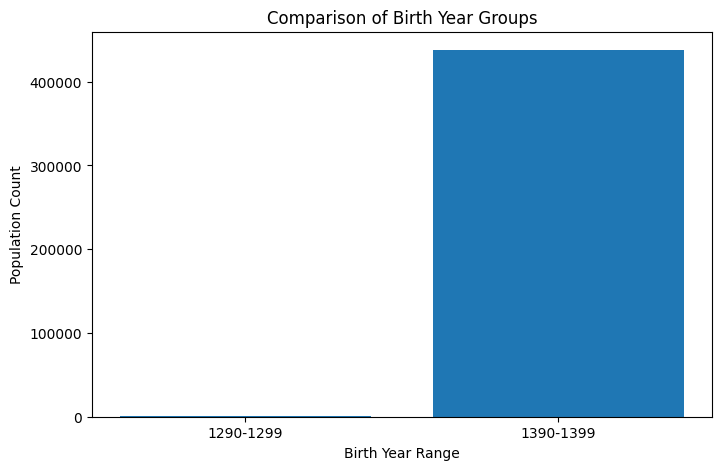

In [7]:
import matplotlib.pyplot as plt


# Counters for birth year groups

count_1290 = 0
count_1390 = 0


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000
):

    # Convert birth date to string
    chunk['BIRTH_DATE'] = (
        chunk['BIRTH_DATE']
        .fillna('')
        .astype(str)
        .str.strip()
    )

    # Extract birth year
    birth_year = pd.to_numeric(
        chunk['BIRTH_DATE'].str[:4],
        errors='coerce'
    )

    # Count individuals in each range
    count_1290 += (
        (birth_year >= 1290) &
        (birth_year <= 1299)
    ).sum()

    count_1390 += (
        (birth_year >= 1390) &
        (birth_year <= 1399)
    ).sum()


# Create chart

plt.figure(figsize=(8, 5))

plt.bar(
    ['1290-1299', '1390-1399'],
    [count_1290, count_1390]
)

plt.title(
    'Comparison of Birth Year Groups'
)

plt.xlabel(
    'Birth Year Range'
)

plt.ylabel(
    'Population Count'
)

plt.show()

# Question 10
Finding customers whose birth date exactly matches the user's birth date (birthday twin search).

In [11]:
# Target birth date

my_birthday = '1385-01-11'


# List for storing matching records

twins = []


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000,
    usecols=[
        'FULL_NAME',
        'BIRTH_DATE',
        'CITY_NAME',
        'PROVINCE_NAME'
    ]
):

    # Convert birth date to string
    chunk['BIRTH_DATE'] = (
        chunk['BIRTH_DATE']
        .fillna('')
        .astype(str)
        .str.strip()
    )

    # Filter matching records
    filtered = chunk[
        chunk['BIRTH_DATE'] == my_birthday
    ]

    # Store results
    twins.append(filtered)


# Merge all matching records

final_fd = pd.concat(
    twins,
    ignore_index=True
)


# Display results

print(final_fd.shape)

final_fd.head()

(268, 4)


,FULL_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME
0,محمد عثمانی,1385-01-11,NaN,NaN
1,فرهاد سابقی سیف الدینی,1385-01-11,بم,کرمان
2,مهدیه فدائی اسلام,1385-01-11,سمنان,سمنان
3,مهناز زرگانی,1385-01-11,اهواز,خوزستان
4,کانی بادسار,1385-01-11,بوکان,اذربایجان غربی


# Question 11
Identifying customers whose father's name contains non-Arabic Persian characters such as گ، چ، پ or ژ.

In [12]:
# List for storing matching records

persian_fathers = []


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000
):

    # Convert father name to string
    chunk['FATHER_NAME'] = (
        chunk['FATHER_NAME']
        .fillna('')
        .astype(str)
    )

    # Filter records
    filtered = chunk[
        chunk['FATHER_NAME']
        .str.contains(
            r'[گچپژ]',
            na=False
        )
    ]

    # Store results
    persian_fathers.append(filtered)


# Merge all matching records

final_fd = pd.concat(
    persian_fathers,
    ignore_index=True
)


# Display results

print(final_fd.shape)

final_fd.head()

(713918, 8)


,national_code,FULL_NAME,FATHER_NAME,BIRTH_DATE,CITY_NAME,PROVINCE_NAME,BIRTH_CITY,BIRTH_PROVINCE
0,20,زهرا صالحی ریحانی,قپانی,1363-06-19,مسجدسلیمان,خوزستان,ایذه,خوزستان
1,37,محمود اعتقادی,هوشنگ,1370-08-18,ایلام,ایلام,ایلام,ایلام
2,60,علیرضا سعیدی,بیگ محمد,1347-01-01,کرج,البرز,تبریز,آذربایجان شرقی
3,95,اشکان عزیزی,سپهدار,1371-09-23,شیراز,فارس,شیراز,فارس
4,192,ندا سلیمان زاده,اسگندر,1358-09-03,گیوی,اردبیل,سنجبد(کوثر),اردبیل


# Question 12
Calculating the total number of customers residing in Khalkhal city, Ardabil Province.

In [13]:
# Counter for residents of Khalkhal

khalkhal_count = 0


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000
):

    # Convert required columns to string
    chunk['PROVINCE_NAME'] = (
        chunk['PROVINCE_NAME']
        .fillna('')
        .astype(str)
    )

    chunk['CITY_NAME'] = (
        chunk['CITY_NAME']
        .fillna('')
        .astype(str)
    )

    # Count matching records
    khalkhal_count += (
        (chunk['PROVINCE_NAME'] == 'اردبیل') &
        (chunk['CITY_NAME'] == 'خلخال')
    ).sum()


# Display result

print(
    f"Number of residents in Khalkhal: {khalkhal_count}"
)

Number of residents in Khalkhal: 28903


# Question 13

A Deterministic Finite Automaton (DFA) is designed to validate surname patterns. The automaton accepts names ending with one of the following suffixes:

- ی
- یی
- پور

After applying the DFA to the dataset, the number of non-standard names is calculated.

In [14]:
# Counter for non-standard names

non_standard_count = 0


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000,
    usecols=['FULL_NAME']
):

    # Convert column to string
    chunk['FULL_NAME'] = (
        chunk['FULL_NAME']
        .fillna('')
        .astype(str)
    )

    # DFA acceptance condition
    accepted_mask = (
        chunk['FULL_NAME'].str.endswith('پور') |
        chunk['FULL_NAME'].str.endswith('یی') |
        chunk['FULL_NAME'].str.endswith('ی')
    )

    # Count rejected names
    non_standard_count += (~accepted_mask).sum()


# Display result

print(
    f"Number of non-standard names: {non_standard_count}"
)

Number of non-standard names: 12090618


# Question 14
Designing an NFA for special loan approval and rejection rules based on surname patterns and birth year conditions.

In [5]:
# Counters

accepted_count = 0
rejected_count = 0


# Process dataset in chunks

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000,
    usecols=[
        'FULL_NAME',
        'BIRTH_DATE'
    ]
):

    # Convert required columns
    chunk['FULL_NAME'] = (
        chunk['FULL_NAME']
        .fillna('')
        .astype(str)
    )

    chunk['BIRTH_DATE'] = (
        chunk['BIRTH_DATE']
        .fillna('')
        .astype(str)
    )

    # Extract surname
    surname = (
        chunk['FULL_NAME']
        .str.split()
        .str[1:]
        .str.join(' ')
        .str.replace('‌', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    # Extract birth year
    birth_year = pd.to_numeric(
        chunk['BIRTH_DATE'].str[:4],
        errors='coerce'
    )

    # Accepted paths
    accepted_mask = surname.isin([
        'رضایی نژاد',
        'محمدی پور'
    ])

    # Rejected path
    rejected_mask = (
        (surname == 'احمدی') &
        (birth_year.between(1370, 1404))
    )

    # Update counters
    accepted_count += accepted_mask.sum()
    rejected_count += rejected_mask.sum()


# Display results

results = {
    'Accepted Customers': accepted_count,
    'Rejected Customers': rejected_count
}

print(results)

{'Accepted Customers': np.int64(3442), 'Rejected Customers': np.int64(41564)}


# Question 15

## Description

In this section, a DFA is designed to validate
Iranian surnames according to the following rules:

1. The surname must end with one of:
   ز ، ژ ، و ، ه

2. Before the last character, at least one vowel
   must appear.

Accepted vowels:

- ا
- آ
- و
- ی

Because the dataset is extremely large, the
operation is performed using chunk-based
processing.

## Objective

Calculate the number of surnames accepted by
the DFA.

In [5]:
accepted_examples = []

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000,
    usecols=['FULL_NAME']
):

    chunk['FULL_NAME'] = (
        chunk['FULL_NAME']
        .fillna('')
        .astype(str)
    )

    surname = (
        chunk['FULL_NAME']
        .str.split()
        .str[-1]
    )

    accepted_mask = (
        surname.str.endswith(('ز', 'ژ', 'و', 'ه'))
        &
        surname.str[:-1].str.contains(
            r'[اآوی]',
            na=False
        )
    )

    accepted_count += accepted_mask.sum()

    # فقط از اولین چانک‌هایی که نتیجه دارند نمونه بردار
    if len(accepted_examples) < 20:

        sample = chunk.loc[
            accepted_mask,
            ['FULL_NAME']
        ].head(20)

        accepted_examples.append(sample)

print(f"Accepted surnames: {accepted_count}")

examples_df = pd.concat(
    accepted_examples,
    ignore_index=True
)

examples_df.head(10)

Accepted surnames: 5501014


,FULL_NAME
0,قربانعلی نامجو
1,وحید بابائی بوراچالو
2,سماح دغاغله
3,شاهین جعفری طسمالو
4,غضنفر جعفرزاده
5,مهدی مهدزاده
6,موسی آقاوندی یگانه
7,علی محمدزاده
8,سعید عظمیان قزل قیه
9,زهرا محمدزاده


# Question 16

## Description

In this section, an NFA is designed to identify
high-risk customers.

A customer is classified as high-risk if at least
two of the following conditions are satisfied:

### Condition A

- Surname is "اصغری" or "جعفری"
- Birth year is between 1360 and 1380

### Condition B

- Province of residence is one of:

  - سیستان و بلوچستان
  - هرمزگان
  - خوزستان

### Condition C

- First name contains the letter:
  - ز
  - ن

Because the dataset is extremely large, the
analysis is performed using chunk-based
processing.

## Objective

Identify and count all customers who satisfy
at least two of the specified conditions.

In [6]:
high_risk_count = 0

for chunk in read_in_chunks(
    "normalized_bank_data.csv",
    1000000,
    usecols=[
        'FULL_NAME',
        'BIRTH_DATE',
        'PROVINCE_NAME'
    ]
):

    chunk['FULL_NAME'] = (
        chunk['FULL_NAME']
        .fillna('')
        .astype(str)
    )

    surname = (
        chunk['FULL_NAME']
        .str.split()
        .str[-1]
    )

    first_name = (
        chunk['FULL_NAME']
        .str.split()
        .str[0]
    )

    birth_year = pd.to_numeric(
        chunk['BIRTH_DATE']
        .astype(str)
        .str[:4],
        errors='coerce'
    )

    cond_a = (
        surname.isin(
            ['اصغری', 'جعفری']
        )
        &
        birth_year.between(
            1360,
            1380
        )
    )

    cond_b = (
        chunk['PROVINCE_NAME']
        .isin([
            'سیستان و بلوچستان',
            'هرمزگان',
            'خوزستان'
        ])
    )

    cond_c = (
        first_name.str.contains(
            r'[زن]',
            na=False
        )
    )

    score = (
        cond_a.astype(int)
        +
        cond_b.astype(int)
        +
        cond_c.astype(int)
    )

    high_risk_count += (
        score >= 2
    ).sum()

print(high_risk_count)

629520


# NFA to DFA Conversion

This NFA is convertible to a DFA because every
NFA has an equivalent DFA that recognizes the
same language.

In this problem, the NFA evaluates three
independent conditions simultaneously.

The NFA can be in multiple states at the same
time, while a DFA must always be in exactly one
state.

During the conversion process, each DFA state
represents a subset of NFA states.

As the number of NFA states increases, the
number of possible subsets also increases.

Therefore, although the conversion is always
possible, the resulting DFA may contain a much
larger number of states.

# Question 17

## Description

In this section, a random account balance is assigned
to each customer in the dataset.

After assigning balances, the wealthiest customer is
identified.

The balance of the wealthiest customer is then
distributed equally among all individuals whose
address is "خوابگاه امینیان".

Because the dataset is extremely large, the
processing is performed using chunk-based
techniques.

## Objective

1. Generate account balances for all customers.
2. Identify the wealthiest customer.
3. Find all individuals whose address is
   "خوابگاه امینیان".
4. Distribute the wealthiest customer's balance
   equally among these individuals.
5. Update the dataset with the new balances.